<style>
/* Enable wrapping of long code lines */
code, pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: break-word !important;
}
</style>

# Principal Component Analysis (PCA) of Twitter Dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/tee._.thy/Desktop/ucd/davis y3/fq25/sta 160/Adjusted_Combined_Truth_Features.csv')


In [3]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(col, df[col].nunique())

author 161
statement_x 1058
manual_keywords 1056
tweet 134198
5_label_majority_answer 5
3_label_majority_answer 2
statement_y 1058


In [4]:
for col in df.select_dtypes(include='number'):
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include='object'):
    df[col] = df[col].astype('category')


In [5]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df.select_dtypes(include='category'):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])


In [6]:
# cut off columns that have more than 20 unique values
low_card_cols = [col for col in categorical_cols if df[col].nunique() < 20]
df_small = df[low_card_cols + df.select_dtypes(include='number').columns.tolist()]
df_encoded = pd.get_dummies(df_small, drop_first=True)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)


In [8]:
pca
principal_components

array([[ 0.00477959, -3.21812337],
       [ 1.50925227, -2.52303599],
       [-2.66583016, -1.83990577],
       ...,
       [ 3.94096852,  2.28696412],
       [-1.81439712,  3.68979244],
       [ 2.03782932,  2.6964669 ]])

In [9]:
# each row is a principal component (a vector of feature weights)
top10_components = pca.components_[:10]

print("Top 10 PCA components (each row is one component):")
print(top10_components)


Top 10 PCA components (each row is one component):
[[ 1.28442215e-01 -1.57829270e-01  1.28442215e-01 -1.57829270e-01
  -6.05786426e-03 -1.02157754e-02 -1.80226882e-02 -1.25022895e-02
   1.75319692e-02  7.14819356e-05 -1.64252580e-03  4.32672172e-04
   1.01547410e-04 -3.24767123e-02  4.75626433e-02  1.94276396e-01
   2.28325418e-01  4.47874868e-01  1.20446867e-01 -4.68185447e-02
  -9.31343377e-02  2.19132257e-01  2.82471630e-01  2.38953366e-01
   1.84290404e-01  7.35873191e-02  2.19466897e-01  2.29585220e-01
   4.55326532e-02  5.21999787e-02  9.90118585e-02  1.44113724e-01
   1.82863772e-01  1.68474273e-01  4.18009301e-01 -1.53083639e-04
  -1.88928631e-03 -1.84866553e-03  1.27203835e-03  4.06480044e-04]
 [ 4.61046946e-01 -4.57214268e-01  4.61046946e-01 -4.57214268e-01
  -2.28775286e-02 -2.59064214e-02 -5.00145930e-02 -3.17751076e-02
   3.20853365e-02  5.34244083e-03  4.63028929e-03  2.63937006e-03
   3.15918509e-03 -5.68220343e-02  6.16905555e-02 -1.73947700e-01
  -1.74086979e-01 -1.199

In [10]:
df_encoded.columns
components_df = pd.DataFrame(
    pca.components_,
    columns=df_encoded.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
pc1 = pd.Series(pca.components_[0], index=df_encoded.columns)
print(pc1.sort_values(ascending=False).head(10))   # top positive contributors
print(pc1.sort_values().head(10))                  # top negative contributors


Word count         0.447875
short_word_freq    0.418009
adpositions        0.282472
pronouns           0.238953
dots               0.229585
total_count        0.228325
conjunctions       0.219467
adverbs            0.219132
unique_count       0.194276
TOs                0.184290
dtype: float64
BinaryNumTarget_x                      -0.157829
BinaryNumTarget_y                      -0.157829
Average word length                    -0.093134
Min word length                        -0.046819
hashtags                               -0.032477
statuses_count                         -0.018023
listed_count                           -0.012502
friends_count                          -0.010216
followers_count                        -0.006058
5_label_majority_answer_Mostly Agree   -0.001889
dtype: float64


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# exclude target
X = df_encoded.drop(columns=['BinaryNumTarget_x', 'BinaryNumTarget_y'])

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# dataframe of PCA
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)


print(X_pca_df.head())


        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.835939  0.048103  2.841792 -1.710386 -0.726997 -0.645175  0.568715   
1  2.181694 -0.100132 -1.185217 -1.986252 -1.027622  0.390112 -1.761427   
2 -2.070285  0.017437  1.177498 -1.220281 -0.670740 -0.173448 -2.688912   
3  1.986215 -0.030876  0.678430 -2.765594 -1.052425 -0.621003  0.915824   
4 -0.295530 -0.060816  0.477973 -1.846606 -1.019870 -0.100072 -0.703789   

        PC8       PC9      PC10  ...      PC19      PC20      PC21      PC22  \
0  0.634206 -0.965475 -0.503468  ...  0.133235 -0.555509  1.410703  0.678580   
1  1.220325  2.184205  0.249864  ...  0.158867  0.750643 -0.094634  0.142767   
2  0.232761  0.332580  0.034287  ...  0.314991 -0.513470 -0.264411  0.307813   
3  0.761422 -0.939778  1.034744  ...  0.055342 -0.383673 -0.712414  0.608562   
4  0.676494  0.291007 -0.181209  ...  0.271279 -0.409432  0.142513  0.123026   

       PC23      PC24      PC25      PC26      PC27      PC28  
0 -0

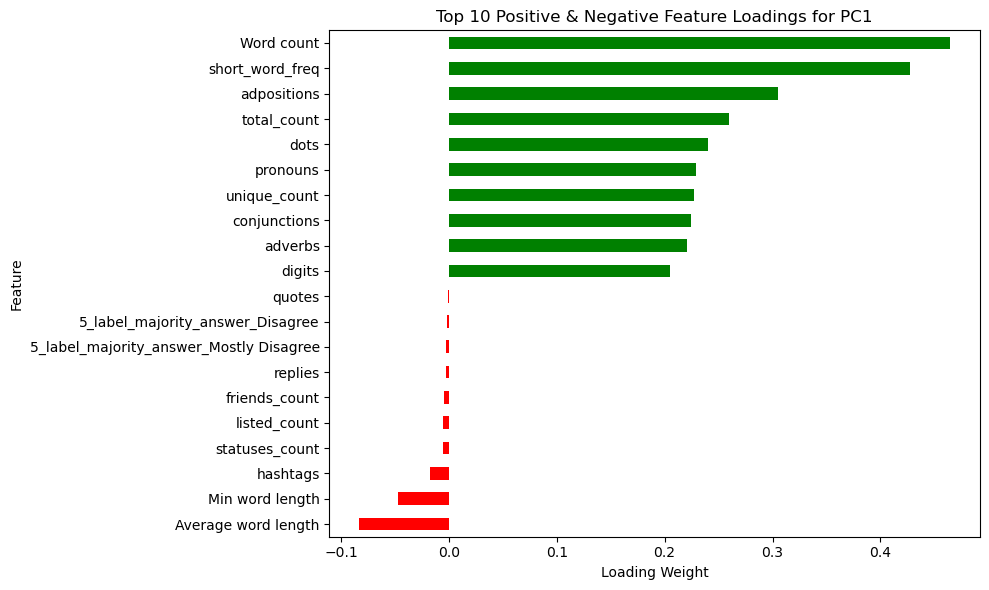

Top 10 positive loadings:
Word count         0.464978
short_word_freq    0.427321
adpositions        0.305026
total_count        0.260007
dots               0.240626
pronouns           0.229071
unique_count       0.227357
conjunctions       0.223968
adverbs            0.220478
digits             0.205345
dtype: float64

Top 10 negative loadings:
Average word length                       -0.083448
Min word length                           -0.047256
hashtags                                  -0.017787
statuses_count                            -0.005676
listed_count                              -0.005365
friends_count                             -0.004249
replies                                   -0.002803
5_label_majority_answer_Mostly Disagree   -0.002599
5_label_majority_answer_Disagree          -0.002084
quotes                                    -0.001341
dtype: float64


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

X = df_encoded.drop(columns=['BinaryNumTarget_x', 'BinaryNumTarget_y'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# map PC1 to feature names
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)

# top 10 loadings
top10_positive = pc1_loadings.sort_values(ascending=False).head(10)
top10_negative = pc1_loadings.sort_values().head(10)
top_features = pd.concat([top10_negative, top10_positive])

# horizontal bar chart 
colors = ['red' if val < 0 else 'green' for val in top_features]

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh', color=colors)
plt.xlabel('Loading Weight')
plt.ylabel('Feature')
plt.title('Top 10 Positive & Negative Feature Loadings for PC1')
plt.tight_layout()
plt.show()

print("Top 10 positive loadings:")
print(top10_positive)
print("\nTop 10 negative loadings:")
print(top10_negative)


In [62]:
print("Columns used for PCA:")
print(list(X.columns))

Columns used for PCA:
['Unnamed: 0', 'followers_count', 'friends_count', 'statuses_count', 'listed_count', 'mentions', 'quotes', 'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count', 'total_count', 'Word count', 'Max word length', 'Min word length', 'Average word length', 'adverbs', 'adpositions', 'pronouns', 'TOs', 'determiners', 'conjunctions', 'dots', 'exclamation', 'questions', 'ampersand', 'capitals', 'digits', 'long_word_freq', 'short_word_freq', '5_label_majority_answer_Disagree', '5_label_majority_answer_Mostly Agree', '5_label_majority_answer_Mostly Disagree', '5_label_majority_answer_NO MAJORITY', '3_label_majority_answer_Disagree']


In [1]:
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)

# top 10 by absolute value
top10 = pc1_loadings.abs().sort_values(ascending=False).head(10)
print("Top contributors (with sign):")
print(pc1_loadings[top10.index])


NameError: name 'pd' is not defined

Sign of loadings don't really matter. It is the overall weight of it (bigger the number the more important it is). To find most relevant features, find the top absolute value feature loadindgs.